In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from empiricaldist import Pmf

In [2]:
x = [1, 3, 5]
y = [2,4]

In [3]:
X, Y = np.meshgrid(x, y)

In [4]:
X

array([[1, 3, 5],
       [1, 3, 5]])

In [5]:
Y

array([[2, 2, 2],
       [4, 4, 4]])

In [6]:
X * Y

array([[ 2,  6, 10],
       [ 4, 12, 20]])

In [7]:
df = pd.DataFrame(X * Y, columns=x, index=y)
df

,1,3,5
2,2,6,10
4,4,12,20


## How tall is A?

In [8]:
mean = 178
qs =np.arange(mean-24, mean +24, 0.5)

In [9]:
std = 7.7
ps = norm(mean, std).pdf(qs)

<Axes: >

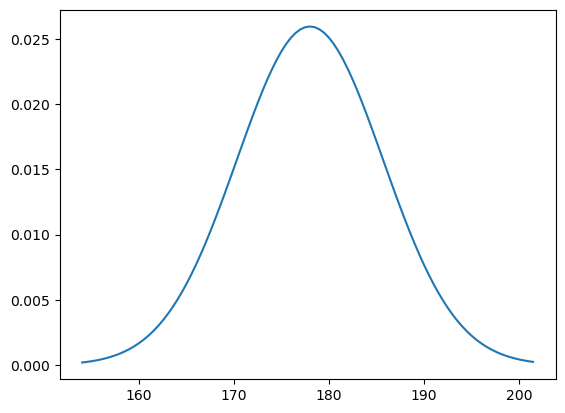

In [10]:
prior = Pmf(ps, qs)
prior.normalize()
prior.plot()

In [11]:
# funtion that takes 2 PMFs and returns a new PMF that is the product of the two PMFs
def product(pmf1, pmf2):
    """Return a new PMF that is the product of the two PMFs."""
    X, Y = np.meshgrid(pmf1, pmf2)
    return pd.DataFrame(X * Y, columns=pmf1.qs, index=pmf2.qs)

In [12]:
joint = product(prior, prior)
joint.shape

(96, 96)

In [13]:
joint.to_numpy().sum()

np.float64(1.0)

In [14]:
#function that plots the joint distribution as a contour plot
def plot_joint(joint, cmap='viridis'):
    """Plot the joint distribution as a colormesh plot."""
    vmax = joint.to_numpy().max() * 1.1
    plt.pcolormesh(joint.columns, joint.index, joint, cmap=cmap, vmax=vmax, shading='nearest')
    plt.colorbar()
    plt.xlabel('A height in cm')
    plt.ylabel('B height in cm')


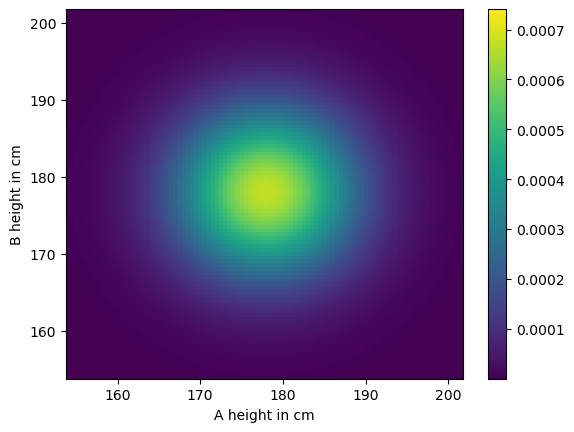

In [15]:
plot_joint(joint)

In [16]:
x = joint.columns
y = joint.index
X, Y = np.meshgrid(x, y)

In [17]:
A_taller = (X>Y)
A_taller.dtype

dtype('bool')

In [18]:
a = np.where(A_taller, 1, 0)

In [19]:
likelihood = pd.DataFrame(a, columns=y, index=x)

In [20]:
posterior = joint * likelihood

In [21]:
# function to normalize the posterior

def normalize(joint):
    """Normalize the joint distribution."""
    prob_data = joint.to_numpy().sum()
    joint /= prob_data
    return prob_data

In [22]:
normalize(posterior)

np.float64(0.49080747821526977)

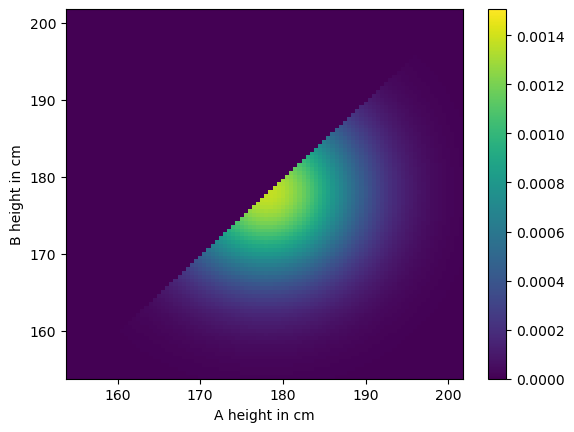

In [23]:
plot_joint(posterior)

In [24]:
# function for marginal distribution
def marginal(joint, axis):
    """Return the marginal distribution."""
    return Pmf(joint.sum(axis=axis))

In [25]:
marginal_A = marginal(posterior, axis=0)
marginal_B = marginal(posterior, axis=1)

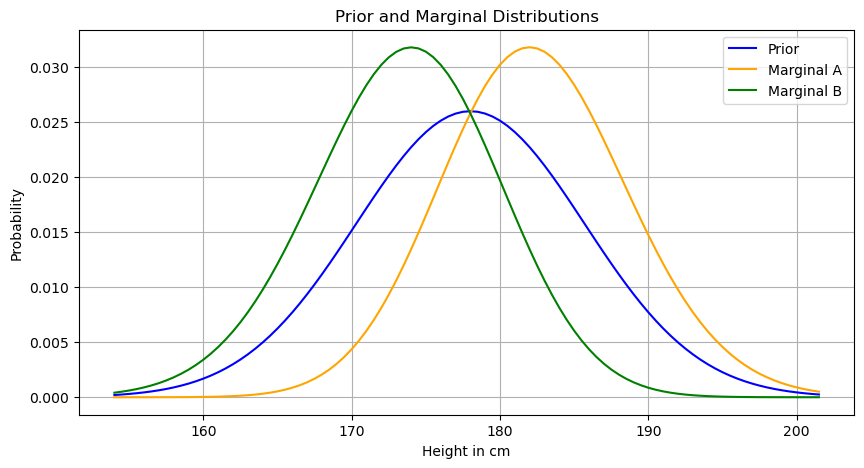

In [26]:
# plot that shows the marginal distribution of A and B and prior distribution on the same plot
plt.figure(figsize=(10, 5)) 
plt.plot(prior.qs, prior.ps, label='Prior', color='blue')
plt.plot(marginal_A.qs, marginal_A.ps, label='Marginal A', color='orange')
plt.plot(marginal_B.qs, marginal_B.ps, label='Marginal B', color='green')
plt.xlabel('Height in cm')
plt.ylabel('Probability')
plt.title('Prior and Marginal Distributions')
plt.legend()
plt.grid()
plt.show()

In [27]:
prior.mean()

np.float64(177.99516026921506)

In [28]:
print(marginal_A.mean(), marginal_B.mean())

182.38728123421683 173.6028600023339


In [29]:
prior.std()

np.float64(7.624924796641578)

In [30]:
print(marginal_A.std(), marginal_B.std())

6.27046117764547 6.280513548175111


In [31]:
column_170 = posterior[170]

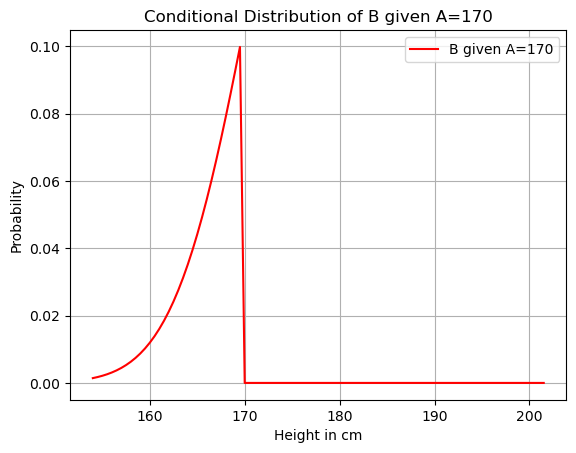

In [32]:
cond_B = Pmf(column_170)
cond_B.normalize()
cond_B.plot(label='B given A=170', color='red')
plt.xlabel('Height in cm')
plt.ylabel('Probability')
plt.title('Conditional Distribution of B given A=170')
plt.legend()
plt.grid()
plt.show()

In [33]:
cond_B.mean()

np.float64(165.89238115512774)